# Linear Algebra Photo Studio
**Matrix multiplication, inversion and photo filters** | UE25MA242A MFAD 2026 mini project (Orange Problem)

A photo is a grid of numbers, so every edit is a matrix operation: **applying** a filter is a matrix *multiplication*,
**undoing** it is a matrix *inversion*. This notebook walks through the whole project using the modules in this repo.

| Section | What you will see |
|---|---|
| 1 | A photo as matrices |
| 2 | The hand-written maths core, checked against NumPy |
| 3 | Colour filters: 3×3 matrix × pixel |
| 4 | Geometric transforms: homogeneous matrices |
| 5 | Convolution filters: im2col and the convolution matrix |
| 6 | Undoing an edit: when the inverse works, and when it does not |
| 7 | Deblurring and ridge regularisation |
| 8 | Our code vs NumPy: speed |

**To run:** open this notebook from the project folder (the one containing `matrix_ops.py`), after `pip install -r requirements.txt`
(plus `pip install notebook` if you do not have Jupyter). To use **your own photo**, change `PHOTO` in section 1.

In [81]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
if not os.path.exists("matrix_ops.py"):
    raise FileNotFoundError("Open this notebook from the project folder (the one containing matrix_ops.py).")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matrix_ops as mo               # hand-written multiply, determinant, inverse, condition number
import utils
import color_filters as cf
import geometric_transforms as gt
import convolution_filters as cv
import inversion_recovery as ir
import app_logic as al

plt.rcParams["figure.dpi"] = 70
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

def show(images, titles, cols=4, size=3.0):
    """Display a grid of images (RGB or grayscale arrays, values 0-255)."""
    rows = -(-len(images) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, im, t in zip(axes, images, titles):
        arr = utils.to_uint8(im)
        ax.imshow(arr, cmap="gray" if arr.ndim == 2 else None, vmin=0, vmax=255, interpolation="nearest")
        ax.set_title(t, fontsize=9)
    plt.tight_layout()
    plt.show()

## 1. A photo is a matrix
An RGB photo is three matrices (red, green, blue) of numbers from 0 to 255, stacked into an array of shape `(H, W, 3)`.
`al.load_image` also corrects phone-photo rotation and shrinks big photos to at most 384 px.

shape (H, W, channels): (288, 384, 3) | dtype: float64 | range: 0 to 255


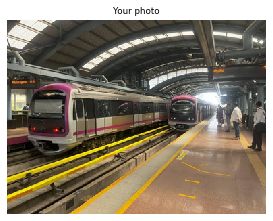

In [82]:
PHOTO = "images/sample_image.jpg"      # <- change this to the path of your own photo
img = al.load_image(PHOTO)       # float array (H, W, 3), values 0-255
h, w, _ = img.shape
print("shape (H, W, channels):", img.shape, "| dtype:", img.dtype, "| range:", round(img.min()), "to", round(img.max()))
show([img], ["Your photo"], cols=1, size=4)

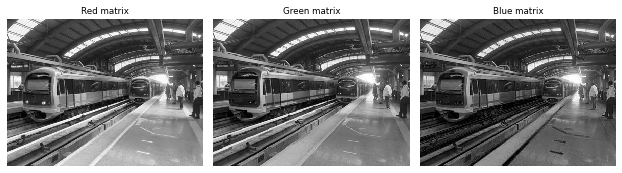

Top-left 4 x 4 block of the red matrix:
[[52. 52. 52. 52.]
 [56. 56. 56. 56.]
 [61. 61. 61. 61.]
 [66. 66. 66. 66.]]

One pixel (row 10, column 10) as a vector [R, G, B]: [101.  97.  91.]


In [83]:
show([img[..., 0], img[..., 1], img[..., 2]], ["Red matrix", "Green matrix", "Blue matrix"], cols=3)
print("Top-left 4 x 4 block of the red matrix:")
print(img[:4, :4, 0].round(0))
print("\nOne pixel (row 10, column 10) as a vector [R, G, B]:", img[10, 10].round(1))

## 2. The maths core (`matrix_ops.py`)
Multiplication (triple loop), determinant (Gaussian elimination) and inverse (Gauss-Jordan on `[A | I]`) are written by hand.
NumPy is used here only to **check** them.

In [84]:
A = rng.random((4, 4)) + np.eye(4)
B = rng.random((4, 4))
print("max |our matmul - NumPy|          :", np.abs(mo.matmul(A, B) - A @ B).max())
print("determinant, ours vs NumPy        :", mo.determinant(A), np.linalg.det(A))
print("max |our inverse - NumPy inverse| :", np.abs(mo.inverse(A) - np.linalg.inv(A)).max())
print("max |A @ A^-1 - I|                :", np.abs(A @ mo.inverse(A) - np.eye(4)).max())

max |our matmul - NumPy|          : 4.440892098500626e-16
determinant, ours vs NumPy        : 3.155368174328781 3.155368174328781
max |our inverse - NumPy inverse| : 2.220446049250313e-16
max |A @ A^-1 - I|                : 2.220446049250313e-16


### Invertible is not the same as safe
The **condition number** `cond(A) = ‖A‖ · ‖A⁻¹‖` is the worst-case factor by which small errors in the data get amplified.
Below, the same tiny change (0.0001) in `b` barely moves the answer for the good matrix but throws the bad one far off.

In [85]:
cases = [("good", np.array([[2., 0.], [0., 1.]]), np.array([2., 1.]), np.array([1e-4, 0.])),
         ("bad",  np.array([[1., 1.], [1., 1.0001]]), np.array([2., 2.0001]), np.array([0., 1e-4]))]
rows = []
for name, M, b, delta in cases:
    rows.append({"matrix": name, "determinant": round(mo.determinant(M), 6), "condition number": round(mo.condition_number(M), 1),
                 "x for b": mo.inverse(M) @ b, "x for b + 0.0001": mo.inverse(M) @ (b + delta)})
pd.DataFrame(rows)

,matrix,determinant,condition number,x for b,x for b + 0.0001
0,good,2.0000,2.0,"[1.0, 1.0]","[1.00005, 1.0]"
1,bad,0.0001,40004.0,"[0.999999999996362, 1.000000000003638]","[-3.637978807091713e-12, 2.000000000003638]"


In [86]:
# The determinant says WHETHER an inverse exists; the condition number says HOW SAFELY you can use it.
for scale in (1, 1e-6, 1e-13):
    M = scale * np.eye(3)
    print(f"{scale:g} * I :  det = {mo.determinant(M):.3g},  cond = {mo.condition_number(M):.3g},  invertible = {mo.is_invertible(M)}")
G = cf.FILTERS["Grayscale"]()
print("\nGrayscale matrix: det =", mo.determinant(G), "| invertible:", mo.is_invertible(G), "| cond =", mo.condition_number(G))

1 * I :  det = 1,  cond = 1,  invertible = True
1e-06 * I :  det = 1e-18,  cond = 1,  invertible = True
1e-13 * I :  det = 1e-39,  cond = 1,  invertible = True

Grayscale matrix: det = 0.0 | invertible: False | cond = inf


## 3. Colour filters: a 3×3 matrix times every pixel
For one pixel `p = [R, G, B]ᵀ` the filtered pixel is `M @ p`. Different matrices give different filters.
The table shows each matrix's determinant, whether it is invertible, and its condition number.

In [87]:
names = list(cf.FILTERS)
facts = pd.DataFrame({n: cf.describe_matrix(cf.FILTERS[n]()) for n in names}).T
facts

,determinant,invertible,condition_number
Grayscale,0.0,False,inf
Sepia (full),0.0,True,28635.024793
Soft sepia,0.180368,True,5.288912
Swap R<->B,-1.0,True,1.0
Brighten,1.728,True,1.0
Saturate,2.25,True,2.248451
Warm tone,0.9775,True,1.352941


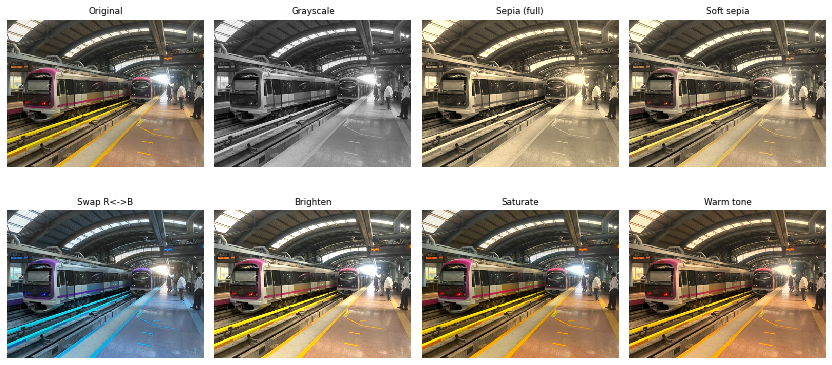

In [88]:
show([img] + [cf.apply_filter(img, n)[0] for n in names], ["Original"] + names, cols=4)

In [89]:
p = np.array([200., 120., 80.])
M = cf.FILTERS["Soft sepia"]()
print("Soft sepia matrix M =\n", M)
print("\nM @ p         =", M @ p)
print("M^-1 @ (M @ p) =", mo.inverse(M) @ (M @ p), "  <- the original pixel is recovered")
G = cf.FILTERS["Grayscale"]()
print("\nGrayscale: M @ p =", G @ p, "(all three channels equal; the colour information is gone)")

Soft sepia matrix M =
 [[0.6358 0.4614 0.1134]
 [0.2094 0.8116 0.1008]
 [0.1632 0.3204 0.4786]]

M @ p         = [191.6   147.336 109.376]
M^-1 @ (M @ p) = [200. 120.  80.]   <- the original pixel is recovered

Grayscale: M @ p = [139.36 139.36 139.36] (all three channels equal; the colour information is gone)


## 4. Geometric transforms: homogeneous 3×3 matrices
A position `(x, y)` is written `[x, y, 1]ᵀ`, which turns rotation, scaling, shear, flips **and translation** into 3×3 matrices.
Several edits combine by **multiplying their matrices**. To draw the result, `warp` uses *inverse mapping*: for every output pixel it applies `T⁻¹`
(our own Gauss-Jordan inverse) to find the source pixel.

In [90]:
C = lambda M: gt.about_center(M, w, h)       # make a transform act around the image centre
R = C(gt.rotation(30))
print("Rotation by 30 degrees about the centre, T =\n", R)
print("\ndet(T) =", round(mo.determinant(R), 6), "(area is preserved)")
print("T @ [100, 50, 1] =", (R @ np.array([100., 50., 1.])).round(2))

Rotation by 30 degrees about the centre, T =
 [[  0.866    0.5    -46.0939]
 [ -0.5      0.866  114.9754]
 [  0.       0.       1.    ]]

det(T) = 1.0 (area is preserved)
T @ [100, 50, 1] = [ 65.51 108.28   1.  ]


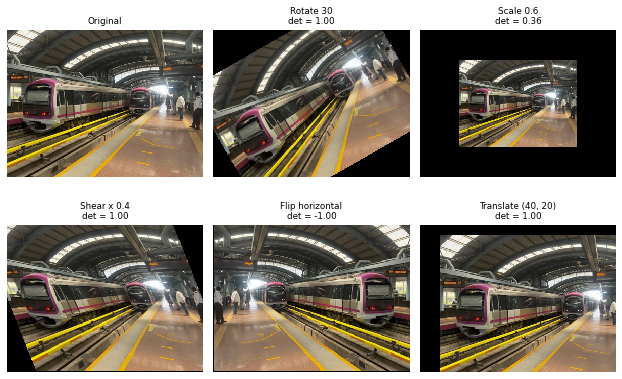

In [91]:
transforms = {"Rotate 30": C(gt.rotation(30)), "Scale 0.6": C(gt.scaling(0.6)), "Shear x 0.4": C(gt.shear(shx=0.4)),
              "Flip horizontal": gt.flip_horizontal(w), "Translate (40, 20)": gt.translation(40, 20)}
show([img] + [gt.warp(img, M) for M in transforms.values()],
     ["Original"] + [f"{n}\ndet = {mo.determinant(M):.2f}" for n, M in transforms.items()], cols=3)

### Order matters
Matrix multiplication is not commutative: rotating then shearing is different from shearing then rotating.

Rotate-then-shear equals shear-then-rotate? False


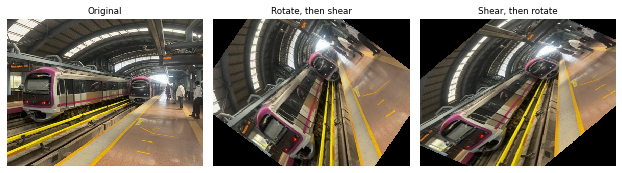

In [92]:
Rm, Sm = C(gt.rotation(40)), C(gt.shear(shx=0.5))
rot_then_shear, shear_then_rot = gt.compose(Rm, Sm), gt.compose(Sm, Rm)     # compose(A, B) applies A first
print("Rotate-then-shear equals shear-then-rotate?", np.allclose(rot_then_shear, shear_then_rot))
show([img, gt.warp(img, rot_then_shear), gt.warp(img, shear_then_rot)],
     ["Original", "Rotate, then shear", "Shear, then rotate"], cols=3)

### Undoing a transform
Apply `T`, then `T⁻¹`. Pixels that were pushed outside the frame cannot come back, so the error is measured only on pixels that stayed inside.

In [93]:
rows = []
for name, M in transforms.items():
    back = gt.warp(gt.warp(img, M), mo.inverse(M))
    keep = gt.warp(gt.warp(np.ones((h, w, 1)), M), mo.inverse(M))[..., 0] > 0.99
    rows.append({"transform": name, "pixels kept (%)": round(keep.mean() * 100, 1),
                 "mean abs error (0-255)": round(float(np.abs(back[keep] - img[keep]).mean()), 3)})
pd.DataFrame(rows)

,transform,pixels kept (%),mean abs error (0-255)
0,Rotate 30,82.4,3.765
1,Scale 0.6,98.8,5.764
2,Shear x 0.4,91.8,1.565
3,Flip horizontal,99.1,0.000
4,"Translate (40, 20)",82.8,0.000


## 5. Convolution filters: blur, sharpen, edges
A kernel slides over the image and each output pixel is a weighted sum of its neighbours. Kernels whose weights **sum to 1** keep brightness;
kernels that **sum to 0** (Laplacian) show only changes, that is, edges.

In [94]:
print("Box blur 3x3:\n", cv.box_blur_kernel(3).round(3))
print("\nSharpen (sum = %g):\n" % cv.sharpen_kernel().sum(), cv.sharpen_kernel())
print("\nSobel x:\n", cv.sobel_x_kernel())
print("\nLaplacian (sum = %g):\n" % cv.laplacian_kernel().sum(), cv.laplacian_kernel())

Box blur 3x3:
 [[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]

Sharpen (sum = 1):
 [[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]

Sobel x:
 [[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Laplacian (sum = 0):
 [[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]


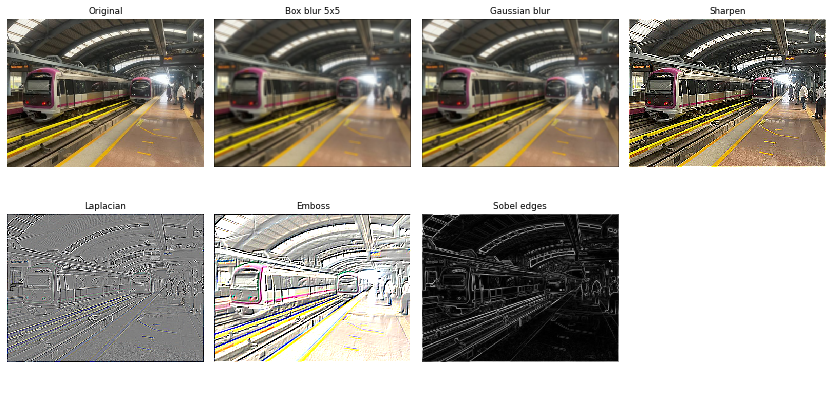

In [95]:
conv_names = list(cv.FILTERS)
mag, gx, gy = cv.sobel_edges(img)           # edge strength = sqrt(Gx^2 + Gy^2)
show([img] + [cv.apply_filter(img, n)[0] for n in conv_names] + [mag], ["Original"] + conv_names + ["Sobel edges"], cols=4)

### Convolution as matrix multiplication (im2col)
Write each pixel's neighbourhood as one **row** of a matrix `P`. Then `output = P @ kernel`. Here on a 3×3 patch with a vertical edge.

In [96]:
patch = np.array([[10, 10, 200], [10, 10, 200], [10, 10, 200]], float)
P = cv.im2col(patch, 3)                      # one row per pixel, one column per kernel cell
print("im2col matrix shape:", P.shape)
print("Neighbourhood of the centre pixel:", P[4])
for name, k in [("box blur", cv.box_blur_kernel(3)), ("sharpen", cv.sharpen_kernel()), ("sobel x", cv.sobel_x_kernel())]:
    value = P[4] @ np.flip(k).ravel()
    print(f"{name:9s}: row . flipped kernel = {value:8.2f}   (cv.convolve gives {cv.convolve(patch, k)[1, 1]:.2f})")

im2col matrix shape: (9, 9)
Neighbourhood of the centre pixel: [ 10.  10. 200.  10.  10. 200.  10.  10. 200.]
box blur : row . flipped kernel =    73.33   (cv.convolve gives 73.33)
sharpen  : row . flipped kernel =  -180.00   (cv.convolve gives -180.00)
sobel x  : row . flipped kernel =  -760.00   (cv.convolve gives -760.00)


### The whole filter as one matrix `T`
For a small image flattened into a vector, `filtered = T @ image_vector`. Because `T` is a matrix we can ask whether it is invertible, and how safely.

In [97]:
gray = cv.to_gray(img)
cy, cx = h // 2, w // 2
small = gray[cy - 3:cy + 4, cx - 3:cx + 4]            # a 7 x 7 patch -> T is 49 x 49
tests = [("Sharpen", cv.sharpen_kernel(), small), ("Box blur 3x3", cv.box_blur_kernel(3), small),
         ("Gaussian 5x5", cv.gaussian_kernel(5, 1.2), small), ("Box blur 3x3 on 8x8", cv.box_blur_kernel(3), gray[cy - 4:cy + 4, cx - 4:cx + 4])]
rows = []
for name, k, patch_ in tests:
    n_ = patch_.shape[0]
    T = cv.convolution_matrix(k, n_, n_)
    same = np.allclose((T @ patch_.ravel()).reshape(n_, n_), cv.convolve(patch_, k))
    rows.append({"filter": name, "T shape": T.shape, "T @ vec == convolve": bool(same),
                 "invertible": mo.is_invertible(T), "condition number": round(mo.condition_number(T), 1)})
pd.DataFrame(rows)

,filter,T shape,T @ vec == convolve,invertible,condition number
0,Sharpen,"(49, 49)",True,True,8.3
1,Box blur 3x3,"(49, 49)",True,True,225.0
2,Gaussian 5x5,"(49, 49)",True,True,6444.5
3,Box blur 3x3 on 8x8,"(64, 64)",True,False,inf


In [98]:
# Independent check against SciPy's convolve2d
try:
    from scipy.signal import convolve2d
    for name, k in [("Gaussian 5x5", cv.gaussian_kernel(5, 1.2)), ("Sobel x", cv.sobel_x_kernel())]:
        ref = convolve2d(gray, k, mode="same", boundary="fill")
        print(f"{name:13s}: max difference vs SciPy = {np.abs(cv.convolve(gray, k) - ref).max():.1e}")
except ImportError:
    print("SciPy is not installed - skipping this check")

Gaussian 5x5 : max difference vs SciPy = 1.1e-13
Sobel x      : max difference vs SciPy = 2.3e-13


## 6. Undoing an edit: when does the inverse work?
`original = M⁻¹ @ edited`. With exact numbers this always works for an invertible `M`. But real images carry rounding and noise,
and ill-conditioned matrices amplify it. Below we add a tiny amount of noise (0.5 grey levels, about the size of 8-bit rounding) to each filtered photo and then invert.

In [99]:
NOISE = 0.5
rows = []
for name in ["Swap R<->B", "Brighten", "Warm tone", "Saturate", "Soft sepia", "Sepia (full)"]:
    M = cf.FILTERS[name]()
    _, back = ir.roundtrip_color(img, M)
    _, back_n = ir.noisy_roundtrip_color(img, M, NOISE, rng)
    err = ir.rmse(back_n, img)
    rows.append({"filter": name, "cond(M)": round(mo.condition_number(M), 2), "RMSE, no noise": f"{ir.rmse(back, img):.1e}",
                 "RMSE, noise 0.5": round(err, 3), "noise amplification": f"x{err / NOISE:.1f}"})
pd.DataFrame(rows)

,filter,cond(M),"RMSE, no noise","RMSE, noise 0.5",noise amplification
0,Swap R<->B,1.00,0.0e+00,0.500,x1.0
1,Brighten,1.00,5.1e-15,0.417,x0.8
2,Warm tone,1.35,5.0e-15,0.512,x1.0
3,Saturate,2.25,1.1e-14,0.400,x0.8
4,Soft sepia,5.29,4.5e-14,1.074,x2.1
5,Sepia (full),28635.02,7.4e-11,3612.885,x7225.8


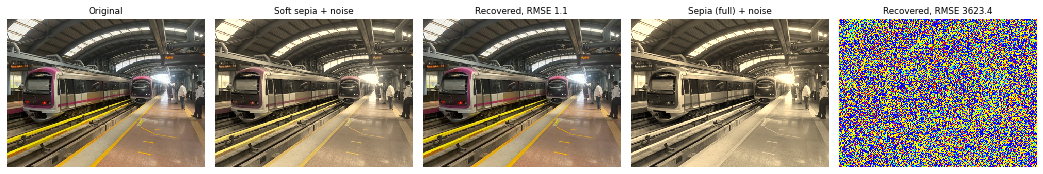

In [100]:
panels, titles = [img], ["Original"]
for name in ["Soft sepia", "Sepia (full)"]:
    M = cf.FILTERS[name]()
    noisy, back_n = ir.noisy_roundtrip_color(img, M, NOISE, np.random.default_rng(7))
    panels += [noisy, back_n]
    titles += [f"{name} + noise", f"Recovered, RMSE {ir.rmse(back_n, img):.1f}"]
show(panels, titles, cols=5)

**Reading the result:** both noisy images look identical to the eye, but soft sepia (cond ≈ 5) recovers cleanly while full sepia (cond ≈ 28,600) turns to static. Notes: Brighten and Saturate scale values up, so inverting them shrinks the noise a little (a factor below 1 is normal), and the exact amplification changes from run to run because the noise is random; it always stays below `cond(M)`.

### A singular matrix cannot be undone, and clipping loses information

In [101]:
G = cf.FILTERS["Grayscale"]()
try:
    mo.inverse(G)
except ValueError as e:
    print("mo.inverse(grayscale) ->", e)
c1, c2 = ir.null_direction_example()
print("\nTwo DIFFERENT colours:", c1.round(1), "and", c2.round(1))
print("Grayscale output of each:", (G @ c1).round(3), "and", (G @ c2).round(3), " -> identical, so the original cannot be recovered")

mo.inverse(grayscale) -> Matrix is singular: inverse does not exist

Two DIFFERENT colours: [100. 100. 100.] and [158.7  70.1 100. ]
Grayscale output of each: [100. 100. 100.] and [100. 100. 100.]  -> identical, so the original cannot be recovered


In [102]:
M = cf.soft_sepia_matrix()
filtered = utils.apply_color_matrix(img, M)
stored = utils.to_uint8(filtered).astype(float)           # saving as an ordinary 8-bit image: clip to 0-255 and round
recovered = utils.apply_color_matrix(stored, mo.inverse(M))
print(f"{(filtered > 255).any(axis=2).mean() * 100:.1f}% of pixels have a channel above 255 and get clipped")
print("RMSE after saving as 8-bit and inverting:", round(ir.rmse(recovered, img), 2), "(M is fine; the clipped values are simply gone)")

4.4% of pixels have a channel above 255 and get clipped
RMSE after saving as 8-bit and inverting: 6.48 (M is fine; the clipped values are simply gone)


## 7. Deblurring and ridge regularisation
To undo a blur we invert the convolution matrix `T`. We use a 16×16 grayscale image so `T` is 256×256. Without noise the inverse is almost exact;
with a little noise it explodes. **Ridge regularisation** `x = (TᵀT + λI)⁻¹ Tᵀ y` adds `λI` to lift the tiny eigenvalues that cause the blow-up.

In [103]:
n = 16
x = ir.downsample_gray(img, n).ravel()
T = cv.convolution_matrix(cv.gaussian_kernel(5, 1.0), n, n)
print("blur matrix T:", T.shape, "| condition number:", round(mo.condition_number(T)))
y = T @ x                                    # blurred image
y_noisy = y + rng.normal(0, 0.5, y.shape)    # plus tiny noise
x_clean = ir.naive_deblur(T, y)
x_naive = ir.naive_deblur(T, y_noisy)
print("error of T^-1 y, no noise        :", f"{ir.rmse(x_clean, x):.1e}")
print("error of T^-1 y, noise 0.5       :", round(ir.rmse(x_naive, x), 1), " (the blurred image alone is off by", round(ir.rmse(y, x), 1), ")")
rows, best = [], None
for lam in [1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
    xr = ir.ridge_deblur(T, y_noisy, lam)
    e = ir.rmse(xr, x)
    rows.append({"lambda": lam, "RMSE": round(e, 2)})
    if best is None or e < best[0]:
        best = (e, lam, xr)
pd.DataFrame(rows)

blur matrix T: (256, 256) | condition number: 1930
error of T^-1 y, no noise        : 1.2e-11
error of T^-1 y, noise 0.5       : 127.9  (the blurred image alone is off by 29.1 )


,lambda,RMSE
0,0.000001,76.64
1,0.000100,13.23
2,0.001000,10.83
3,0.010000,15.56
4,0.100000,25.81
5,1.000000,64.67


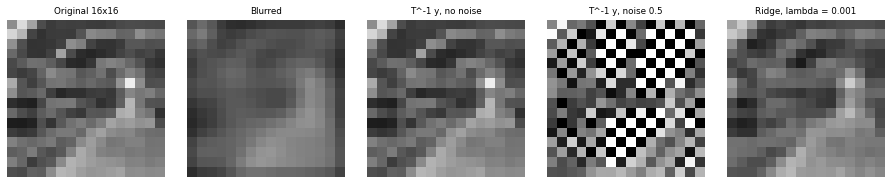

Note: lambda was picked by comparing with the true image, so this is a best case.


In [104]:
panels = [a.reshape(n, n) for a in (x, y, x_clean, x_naive, best[2])]
show(panels, ["Original 16x16", "Blurred", "T^-1 y, no noise", "T^-1 y, noise 0.5", f"Ridge, lambda = {best[1]:g}"], cols=5, size=2.6)
print("Note: lambda was picked by comparing with the true image, so this is a best case.")

## 8. Our code vs NumPy: speed
The hand-written routines are correct but slow, because they loop in Python. That is why the app applies the small 3×3 matrices with NumPy over whole images.
Exact timings depend on your machine.

In [105]:
def best_time(fn, reps):
    best = float("inf")
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

rows = []
for n_ in (10, 20, 40):
    A_, B_ = rng.random((n_, n_)), rng.random((n_, n_))
    ours, theirs = best_time(lambda: mo.matmul(A_, B_), 2), best_time(lambda: A_ @ B_, 200)
    rows.append({"matrix size": n_, "ours (s)": round(ours, 5), "NumPy (s)": f"{theirs:.1e}", "slowdown": f"{ours / theirs:,.0f}x"})
pd.DataFrame(rows)

,matrix size,ours (s),NumPy (s),slowdown
0,10,0.00136,4.0e-06,340x
1,20,0.00314,2.2e-06,"1,428x"
2,40,0.02573,7.5e-06,"3,431x"


In [106]:
crop = img[:64, :64]
M = cf.soft_sepia_matrix()
def per_pixel():
    out = np.empty_like(crop)
    for i in range(64):
        for j in range(64):
            out[i, j] = mo.matmul(M, crop[i, j].reshape(3, 1)).ravel()     # our matmul, one pixel at a time
    return out
t_loop, t_vec = best_time(per_pixel, 1), best_time(lambda: utils.apply_color_matrix(crop, M), 50)
print(f"per-pixel loop with our matmul : {t_loop:.4f} s")
print(f"one vectorised product         : {t_vec:.6f} s  ({t_loop / t_vec:,.0f}x faster)")
print("identical results              :", np.allclose(per_pixel(), utils.apply_color_matrix(crop, M)))

per-pixel loop with our matmul : 0.0355 s
one vectorised product         : 0.000024 s  (1,456x faster)
identical results              : True


## Summary
- A photo is a matrix, and **filters are matrix products**: 3×3 on pixel colours, 3×3 homogeneous on positions, and `P @ kernel` (or one big `T`) for blur, sharpen and edges.
- **Undoing** an edit is multiplying by `M⁻¹`, which we computed ourselves with Gauss-Jordan.
- The **determinant** tells you *whether* an inverse exists (grayscale: no). The **condition number** tells you *how safely* (full sepia and blurs: barely).
- Clipping and cropping lose information that no inverse can restore.
- Regularisation (ridge) trades a little accuracy for stability when a matrix is ill-conditioned.